# Lab 1-2 - Środowisko Programistyczne + Wprowadzenie do uczenia maszynowego

## Konfiguracja środowiska programistycznego
### Google Colab: https://colab.research.google.com/github/yy/dviz-course/blob/master/docs/m01-intro/lab01.ipynb
### Pycharm: https://www.jetbrains.com/help/pycharm/creating-virtual-environment.html

## Przydatne linki

### Integracja Colab-GitHub: https://colab.research.google.com/github/googlecolab/colabtools/blob/master/notebooks/colab-github-demo.ipynb

### Synchronizacja Pycharm-Github: https://www.jetbrains.com/help/pycharm/github.html

### Podstawy operacji na ramkach danych w Pandas: https://www.kaggle.com/learn/pandas

### Tworzenie wykresów w seaborn: https://www.kaggle.com/code/vijayjoshi17/seaborn-guide-all-important-plots

# Zadania:



## Ocena zadań
### Zasady oceniania dla listy 1:
Student w ciągu 5-6 minut prezentuje i omawia napisany przez siebie kod, a następnie prowadzący zadaje 1-2 pytania do całości listy w celu werfikacji czy student rozumie kod, który zaprezentował.

Za każde zadanie można dostać maksymalnie 2 punkty.

### Ocena jest redukowana o 1 punkt w przypadku:
- niepełnej realizacji polecenia (np. brak jednego z podpunktów)
- niezdolności do odpowiedzi na pytanie ze zrozumienia kodu
- popełnienia błędu w kodzie

## Wykorzystywane zbiory danych
Poniższa lista zadań wykorzystuje dwa zbiory danych dostępne na platformie Kaggle:

### Dla zadań 1-4:

Student Lifestyle and Academic Performance Dataset: https://www.kaggle.com/datasets/sehaj1104/student-lifestyle-and-academic-performance-dataset

### Dla zadania nr 5:

Social Media Viral Content and Engagement Metrics: https://www.kaggle.com/datasets/aliiihussain/social-media-viral-content-and-engagement-metrics

## Dokumentacje bibliotek potrzebnych do realizacji zadań:
- pandas: https://pandas.pydata.org/docs/index.html
- seaborn: https://seaborn.pydata.org/
- matplotlib: https://matplotlib.org/stable/


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv('/content/student_lifestyle_performance_dataset.csv')
data2=pd.read_csv('/content/social_media_viral_content_dataset.csv')

## Zadanie 1
Wyświetl ramkę danych spełniającą następujące kryteria:
- ramka zawiera wyłącznie informacje o wieku studentów oraz tym jak spędzają czas.
- ramka zawiera informacje wyłącznie o 15 studentach z najwyższą średnią (CGPA)
- ramka jest posortowana pod względem średniej, tak by student z najwyższą średnią był wyświetlany jako pierwszy

In [4]:
s_info = data[['Age','Study_Hours_per_Day','Sleep_Hours','Screen_Time_Hours','Gym_Hours_per_Week', 'CGPA']]
s_info=s_info.sort_values(by='CGPA', ascending=False)


print(s_info[:15])

     Age  Study_Hours_per_Day  Sleep_Hours  Screen_Time_Hours  \
657   22                 6.85         8.45               3.84   
109   23                 5.83         9.26               7.19   
843   24                 4.64         8.34               3.28   
405   17                 6.87         7.92               2.21   
464   25                 5.18         9.13               7.92   
171   20                 8.05         7.34               6.46   
475   19                 5.71         8.07               2.98   
639   19                 7.30         8.57               3.96   
659   20                 3.85         9.22               7.14   
682   25                 4.87         8.25               4.95   
156   24                 5.41         7.66               5.62   
902   25                 7.70         6.21               4.73   
904   19                 5.50         6.13               2.12   
940   24                 5.54         9.41               4.70   
768   24                 

## Zadanie 2
dodaj do ramki danych kolumnę z wyliczoną średnią ilością czasu wolnego, którym student dysponuje w ciągu dnia.


### Wyliczając wartość czasu wolnego przyjmij następujące założenia:
- czas wolny studenta to cały czas, którego **NIE** poświęca na naukę, ćwiczenia, sen oraz siedzenie przed ekranem oraz na jedzenie i czynności higieniczne
- około godzina czasu spędzonego przed ekranem to czas poświęcony na naukę
- jedzenie i czynności higieniczne zajmują przeciętnej osobie 2,5 godziny w ciągu dnia

### Następnie wyświetl otrzymaną ramkę danych tak, by spełniała następujące kryteria:
- wyświetl wyłącznie dodatkową kolumnę oraz kolumny wykorzystane do wyliczenia ilości czasu wolnego
- kolumna z czasem wolnym powinna wyświetlać się jako pierwsza z lewej
- czas wolny powinien być zaokrąglony do drugiej liczby po przecinku

In [5]:
s_info2 = data.copy()
s_info2['Occupied_time'] = s_info2['Study_Hours_per_Day']-0.5+s_info2['Sleep_Hours']+s_info2['Screen_Time_Hours']+s_info2['Gym_Hours_per_Week']/7+2.5
s_info2.insert(12, 'Free time', 24-s_info2['Occupied_time'])
s_info2['Free time'] = s_info2['Free time'].round(2)
s_info2[['Free time', 'Occupied_time']]

,Free time,Occupied_time
0,1.41,22.591429
1,5.19,18.810000
2,10.04,13.960000
3,1.58,22.420000
4,3.86,20.138571
...,...,...
995,6.10,17.895714
996,7.14,16.858571
997,4.65,19.350000
998,3.24,20.760000


## Zadanie 3
utwórz ramkę danych pozwalającą odpowiedzieć na następujące pytania
- Jaka dziedzina naukowa (*Branch*) jest najbardziej stresująca?
- Czy mediana snu wśród studentów informatyki (*IT*) jest wyższa niż wśród studentów mechaniki (*Mechanical*)?
### UWAGA!
Uwzględnij wyłącznie informacje o pełnoletnich studentach.

In [6]:
#2 agregacje danych: jak stresująca i mediana
s_info3 = data[data['Age']>=18]

branch_info=s_info3.groupby('Branch')['Stress_Level_1_to_10'].sum().reset_index()
branch_info = branch_info.sort_values(by="Stress_Level_1_to_10", ascending=False)
print(branch_info[:1])

sleep_info=s_info3.groupby('Branch')['Sleep_Hours'].median()
print(sleep_info)
if sleep_info.loc['IT']>sleep_info.loc['Mechanical']:
  print("Mediana snu wśród studentów informatyki jest wyższa niż wśród studentów mechaniki")
elif sleep_info.loc['IT']<sleep_info.loc['Mechanical']:
  print("Mediana snu wśród studentów informatyki jest niższa niż wśród studentów mechaniki")
else:
  print("Mediany snu są równe")


  Branch  Stress_Level_1_to_10
1  Civil                750.14
Branch
CSE           6.540
Civil         6.710
ECE           6.405
Electrical    6.310
IT            6.755
Mechanical    6.640
Name: Sleep_Hours, dtype: float64
Mediana snu wśród studentów informatyki jest wyższa niż wśród studentów mechaniki


## Zadanie 4
Przedstaw na wykresach:
- zależność między czasem snu a osiąganą średnią z uwzględnieniem diety studenta
- średnią obecność na zajęciach dla poszczególnych dziedzin naukowych
### UWAGA!
potraktuj informatykę (*IT*) i inżynierię komputerową (*CSE*) jako jedną dziedzinę

/tmp/ipykernel_751/674687602.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_info4["Branch"]=s_info4["Branch"].replace({"IT": "IT&CSE", "CSE": "IT&CSE"})


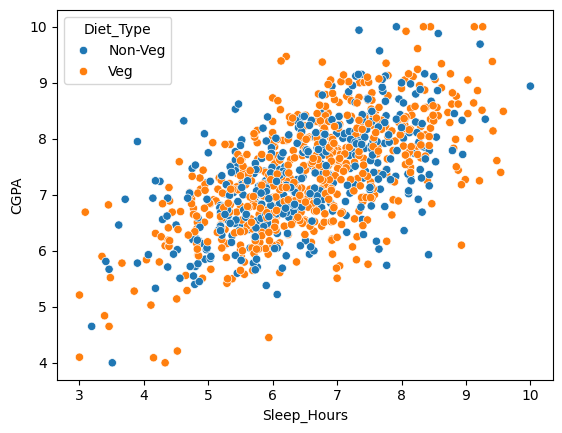

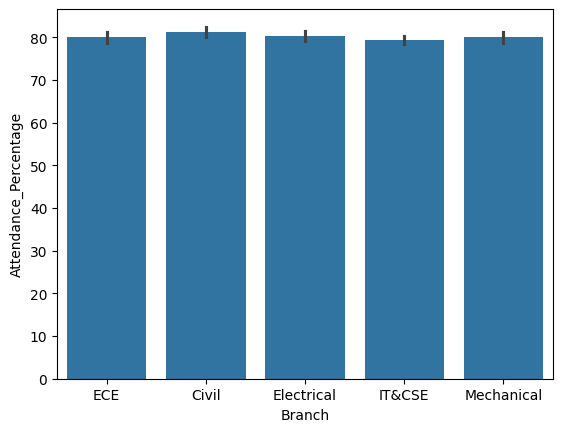

In [7]:
s_info4=data[["Branch", "Sleep_Hours", "CGPA", "Diet_Type", "Attendance_Percentage"]]
s_info4["Branch"]=s_info4["Branch"].replace({"IT": "IT&CSE", "CSE": "IT&CSE"})

sns.scatterplot(data=s_info4, x="Sleep_Hours", y="CGPA", hue="Diet_Type")
plt.show()
sns.barplot(data=s_info4, x="Branch", y="Attendance_Percentage")
plt.show()

## Zadanie 5:
Utwórz wykresy, które pozwalają przedstawić następujące informacje:
- Najpopularniejsze tematy filmów na YouTube Shorts w ostatnim kwartale 2024 roku
- Jaki hasztag najbardziej opłaca się umieszczać w  postach na poszczególnych platformach?

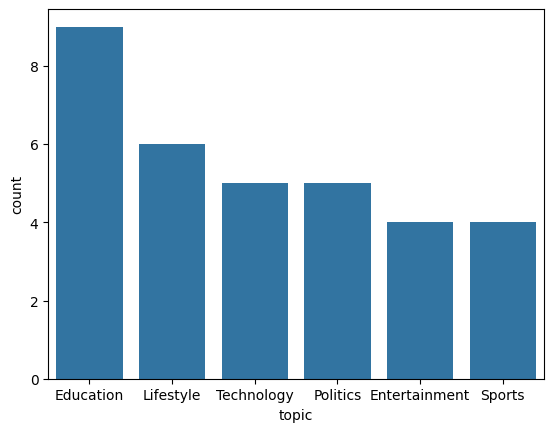

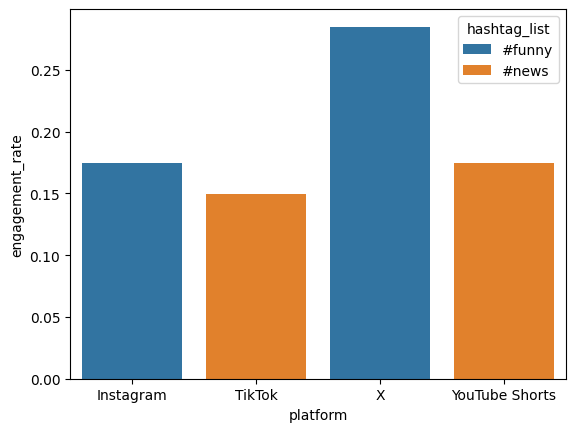

In [15]:
data2["post_datetime"]=pd.to_datetime(data2["post_datetime"])
info1=data2[(data2["platform"]=="YouTube Shorts") & (data2["content_type"]=="video") & (data2["post_datetime"].dt.year==2024) & (data2["post_datetime"].dt.quarter==4)]
sns.countplot(data=info1, x="topic", order=info1['topic'].value_counts().index)
plt.show()

#jako wskaźnik opłacalności wybrałam engagement_rate
info2=data2.copy()
info2["hashtag_list"]=info2["hashtags"].str.strip().str.split()
info2_exploded=info2.explode("hashtag_list")
info2_exploded = info2_exploded[['platform', 'hashtag_list', 'engagement_rate']]
grouped_data = info2_exploded.groupby(['platform', 'hashtag_list'])['engagement_rate'].mean().reset_index()
best_indices = grouped_data.groupby('platform')['engagement_rate'].idxmax()
top_hashtags = grouped_data.loc[best_indices]
sns.barplot(data=top_hashtags,x='platform',y='engagement_rate',hue='hashtag_list')
plt.show()